# KLASIFIKASI GENRE GAME BERDASARKAN SINOPSIS
---
**Author:** *Muhammad Wira Widhana [24.55.2717]*

## Library & Load Dataset

library 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import ast
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# pertama kali saja:

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# digunakan di preprocessing
english_stopwords = set(stopwords.words('english'))
stemmer = PorterStemmer()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ShirO_KurO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ShirO_KurO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ShirO_KurO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Load dan Memeriksa Data (Data Loading & EDA)

Load Dataset

In [3]:
# Load Dataset
df_raw = pd.read_csv('games_fixed.csv')

print("Ukuran awal dataset:", df_raw.shape)
df_raw.head()

Ukuran awal dataset: (122611, 36)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Median playtime two weeks,Average playtime forever,Median playtime forever,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,10,Counter-Strike,"Nov 1, 2000",10000000 - 20000000,7323,0,1.99,80,0,Play the world's number 1 online action game. ...,...,99,10735,185,['Valve'],['Valve'],"['Multi-player', 'PvP', 'Online PvP', 'Shared/...",['Action'],"{'Action': 5504, 'FPS': 4929, 'Multiplayer': 3...",['https://shared.akamai.steamstatic.com/store_...,[]
1,100,Counter-Strike: Condition Zero,"Mar 1, 2004",10000000 - 20000000,83,0,1.99,80,0,"With its extensive Tour of Duty campaign, a ne...",...,1,431,32,['Valve'],['Valve'],"['Single-player', 'Multi-player', 'Color Alter...",['Action'],"{'Action': 1339, 'FPS': 979, 'Shooter': 723, '...",['https://shared.akamai.steamstatic.com/store_...,[]
2,1000000,ASCENXION,"May 14, 2021",0 - 20000,0,0,1.49,0,1,ASCENXION is a 2D shoot 'em up game where you ...,...,0,0,0,['IndigoBlue Game Studio'],['PsychoFlux Entertainment'],"['Single-player', 'Steam Achievements', 'Parti...","['Action', 'Adventure', 'Indie']","{""Shoot 'Em Up"": 186, 'Metroidvania': 181, 'Bu...",['https://shared.akamai.steamstatic.com/store_...,[]
3,1000010,Crown Trick,"Oct 16, 2020",500000 - 1000000,14,0,4.99,0,2,Crown Trick is a beautifully animated rogue-li...,...,0,702,397,['NEXT Studios'],"['Team17', 'NEXT Studios']","['Single-player', 'Steam Achievements', 'Steam...","['Adventure', 'Indie', 'RPG', 'Strategy']","{'Rogue-like': 275, 'Turn-Based Combat': 258, ...",['https://shared.akamai.steamstatic.com/store_...,[]
4,1000030,"Cook, Serve, Delicious! 3?!","Oct 14, 2020",100000 - 200000,27,0,4.99,75,1,Hit the road in this massive sequel to the mil...,...,0,281,118,['Vertigo Gaming Inc.'],['Vertigo Gaming Inc.'],"['Single-player', 'Multi-player', 'Co-op', 'Sh...","['Action', 'Indie', 'Simulation', 'Strategy']","{'Typing': 227, 'Management': 219, 'Difficult'...",['https://shared.akamai.steamstatic.com/store_...,[]


>Penjelasan singkat: Membaca dataset `games_fixed.csv` yang merupakan dataset dari kaggle 

Exploratory Data Analysis (EDA)

In [4]:
# Exploratory Data Analysis (EDA)

df = df_raw[['Name', 'About the game', 'Genres']].copy()

df.rename(columns={
    'Name': 'title',
    'About the game': 'synopsis',
    'Genres': 'genre_raw'
}, inplace=True)

print("Jumlah data setelah seleksi kolom:", df.shape)
df.sample(5)

Jumlah data setelah seleksi kolom: (122611, 3)


,title,synopsis,genre_raw
48558,Heroes Stand Tall: M.E.T.A Beta,NaN,[]
118239,Zodicat,Zodicat is a pacifist cat who wants to protect...,"['Action', 'Casual', 'Indie']"
44665,Hexagonal Explods,Hexagonal Explods is a game about exploding th...,['Action']
121907,Brick Breaker Halloween,About Brick Breaker Halloween Arkanoid is a re...,"['Action', 'Casual', 'Indie']"
85461,740 Racing,Drive around and drift in a fantastic environm...,['Racing']


Cek missing values

In [5]:
# Cek missing values
df.isna().sum()

title           1
synopsis     8448
genre_raw       0
dtype: int64

Hapus baris yang tidak punya sinopsis atau genre

In [6]:
# Hapus baris yang tidak punya sinopsis atau genre
df = df.dropna(subset=['synopsis', 'genre_raw']).reset_index(drop=True)

# Tambahan: hapus genre yang kosong secara konten, seperti [], [''], dll.
df['genre_raw'] = df['genre_raw'].astype(str).str.strip()

# Filter keluar string yang merepresentasikan list kosong
df = df[~df['genre_raw'].isin(['[]', "['']", '[""]', '', 'nan'])].reset_index(drop=True)

print("Jumlah data setelah drop NA dan genre kosong:", df.shape)

Jumlah data setelah drop NA dan genre kosong: (114022, 3)


In [7]:
df.sample(5)

,title,synopsis,genre_raw
74164,The Japanese Calligraphy,Live Streaming and Gameplay Welcome!! **[Calli...,['Simulation']
107931,Katie,Now with full Vive VR support! An isolated tow...,['Indie']
49012,Hanctt Origins,Hanctt is a continent covered in fog. Survivin...,"['Action', 'Adventure', 'Indie', 'RPG']"
103540,Turf Wars,Turf Wars is a chaotic top-down local multipla...,"['Action', 'Indie']"
16829,Overslept,Jazlynn loves naps. As a psychologist working ...,"['Adventure', 'Indie', 'Strategy']"


Normalisasi Genre

In [8]:
target_genres = {'action', 'adventure', 'rpg', 'simulation', 'casual', 'indie'}

def parse_genre_list(genre_str):
    """
    Parse string genre seperti "['Action', 'Indie']" menjadi list python ['action', 'indie'].
    Tidak melakukan penghapusan manual karakter [ ] dengan replace,
    melainkan parsing aman menggunakan ast.literal_eval.
    """
    if pd.isna(genre_str):
        return []
    
    # Jika sudah list, kembalikan langsung
    if isinstance(genre_str, list):
        raw_list = genre_str
    else:
        text = str(genre_str).strip()
        try:
            # Coba parse sebagai literal Python
            raw_list = ast.literal_eval(text)
        except (ValueError, SyntaxError):
            # Jika gagal, fallback split sederhana dengan koma
            raw_list = [g.strip() for g in text.split(',')]
    
    # Normalisasi ke huruf kecil tanpa spasi ekstra
    cleaned = [g.strip().lower() for g in raw_list if isinstance(g, str)]
    return cleaned

# Terapkan parsing ke seluruh kolom genre_raw
df['genre_list'] = df['genre_raw'].apply(parse_genre_list)

# Ambil hanya genre yang termasuk subset target
df['genre_filtered'] = df['genre_list'].apply(
    lambda lst: [g for g in lst if g in target_genres]
)

# Hitung panjang list hasil filter
df['genre_count'] = df['genre_filtered'].apply(len)

print("Distribusi jumlah genre target per game:")
print(df['genre_count'].value_counts().sort_index())

Distribusi jumlah genre target per game:
genre_count
0     3968
1    22223
2    39684
3    31891
4    12428
5     3055
6      773
Name: count, dtype: int64


In [9]:
df.sample(5)

,title,synopsis,genre_raw,genre_list,genre_filtered,genre_count
104486,Break the Game,. Hey I'm Kevin . Something is keeping me in h...,"['Adventure', 'Indie']","[adventure, indie]","[adventure, indie]",2
20608,Miss Furry,General Miss Furry is an Pleasurable Arcade Ga...,"['Action', 'Adventure', 'Casual', 'Indie', 'RP...","[action, adventure, casual, indie, rpg, strategy]","[action, adventure, casual, indie, rpg]",5
92531,Slide! Throw! Snow Party,Enjoy a variety of wintry party games with sim...,"['Action', 'Casual', 'Indie', 'Racing']","[action, casual, indie, racing]","[action, casual, indie]",3
21469,Anvil Saga,Turn a ramshackle blacksmith shop into a succe...,"['Indie', 'RPG', 'Simulation']","[indie, rpg, simulation]","[indie, rpg, simulation]",3
104779,Hyper Knights: Battles,"Spartans vs Persians, Ogres vs Chickens, Marin...","['Indie', 'Simulation', 'Strategy']","[indie, simulation, strategy]","[indie, simulation]",2


In [10]:
# Untuk menjaga single-label classification sesuai proposal,
# hanya ambil data yang memiliki tepat satu genre target
df_single = df[df['genre_count'] == 1].copy().reset_index(drop=True)

# Ambil genre utama
df_single['genre_main'] = df_single['genre_filtered'].str[0]

print("Jumlah data setelah filter subset genre dan single-label:", df_single.shape)
df_single[['title','synopsis' , 'genre_raw', 'genre_list', 'genre_filtered', 'genre_main']].head(10)

Jumlah data setelah filter subset genre dan single-label: (22223, 7)


,title,synopsis,genre_raw,genre_list,genre_filtered,genre_main
0,Counter-Strike,Play the world's number 1 online action game. ...,['Action'],[action],[action],action
1,Counter-Strike: Condition Zero,"With its extensive Tour of Duty campaign, a ne...",['Action'],[action],[action],action
2,Hellish Quart,Hellish Quart is a local-only (two players pla...,"['Action', 'Early Access']","[action, early access]",[action],action
3,WRATH: Aeon of Ruin,You are Outlander. Once adrift upon the Ageles...,['Action'],[action],[action],action
4,The ScreaMaze,Gameplay: Take your mouse and try to reach the...,['Indie'],[indie],[indie],indie
5,RogueCraft Squadron,RogueCraft Squadron is a fast paced real-time ...,"['Indie', 'Strategy']","[indie, strategy]",[indie],indie
6,Glorious Companions,Glorious Companions is a turn-based tactical R...,"['RPG', 'Strategy']","[rpg, strategy]",[rpg],rpg
7,Angry Birds VR: Isle of Pigs,"Join Red, Chuck, Bomb and the Blues to save th...",['Casual'],[casual],[casual],casual
8,VR Flight Simulator New York - Cessna,VR Flight Simulator New York - Cessna is the u...,['Simulation'],[simulation],[simulation],simulation
9,Kebab Chefs! - Restaurant Simulator,◆ You wouldn't say no for a little help with t...,"['Simulation', 'Early Access']","[simulation, early access]",[simulation],simulation


sebaran genre

In [11]:
df_single['genre_main'].value_counts()

genre_main
indie         5780
casual        4791
action        4485
simulation    2768
adventure     2581
rpg           1818
Name: count, dtype: int64

## Filter Bahasa Inggris & Text Cleaning

In [12]:
# TEXT CLEANING & LANGUAGE FILTERING (ENGLISH-ONLY)
def basic_english_filter(text):
    
    # Filter sederhana untuk memastikan sinopsis dominan karakter Latin dan tidak terlalu pendek.
   
    if not isinstance(text, str):
        return False
    
    clean = re.sub(r'[^A-Za-z\s]', ' ', text)
    clean = re.sub(r'\s+', ' ', clean).strip()
    
    if len(clean.split()) < 3:
        return False
    
    ratio = len(clean) / max(len(text), 1)
    return ratio >= 0.7

df_single['is_english'] = df_single['synopsis'].apply(basic_english_filter)
print(df_single['is_english'].value_counts())

df_single = df_single[df_single['is_english']].drop(columns=['is_english']).reset_index(drop=True)
print("Jumlah data setelah filter bahasa Inggris:", df_single.shape)

is_english
True     21794
False      429
Name: count, dtype: int64
Jumlah data setelah filter bahasa Inggris: (21794, 7)


Penghapusan Sinopsis Terlalu Pendek

In [13]:
# SHORT SYNOPSIS REMOVAL BASED ON LENGTH DISTRIBUTION

df_single['word_count'] = df_single['synopsis'].apply(lambda x: len(str(x).split()))

print(df_single['word_count'].describe())

p5  = np.percentile(df_single['word_count'], 5)
p10 = np.percentile(df_single['word_count'], 10)

print(f"Persentil ke-5  : {p5:.0f} kata")
print(f"Persentil ke-10 : {p10:.0f} kata")

count    21794.000000
mean       212.344361
std        158.819862
min          3.000000
25%        113.000000
50%        174.000000
75%        265.000000
max       3363.000000
Name: word_count, dtype: float64
Persentil ke-5  : 57 kata
Persentil ke-10 : 74 kata


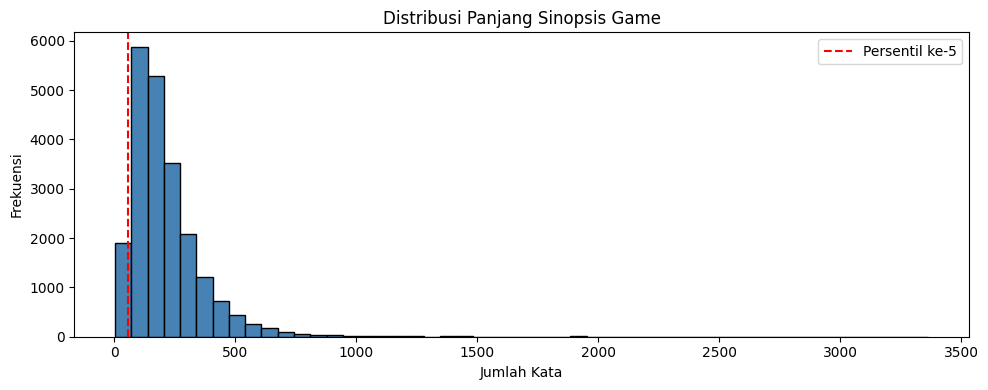

In [14]:
plt.figure(figsize=(10,4))
plt.hist(df_single['word_count'], bins=50, color='steelblue', edgecolor='black')
plt.axvline(p5, color='red', linestyle='--', label='Persentil ke-5')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.title('Distribusi Panjang Sinopsis Game')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Tetapkan threshold minimal berdasarkan persentil ke-5
threshold = int(p5)
print("Threshold minimum panjang sinopsis:", threshold, "kata")

before = len(df_single)
df_single = df_single[df_single['word_count'] >= threshold].reset_index(drop=True)
after = len(df_single)

print("Data sebelum filtering :", before)
print("Data setelah filtering  :", after)
print("Data yang dihapus       :", before - after, f"({(before-after)/before*100:.2f}%)")

df_single = df_single.drop(columns=['word_count'])

Threshold minimum panjang sinopsis: 57 kata
Data sebelum filtering : 21794
Data setelah filtering  : 20735
Data yang dihapus       : 1059 (4.86%)


## PRE-Prosessing


preprocessing mencakup case folding, tokenizing, stopword removal, dan stemming, dan batasan masalah perubahan kombinasi fitur preprocessing.

Skenario:

- S1: Case folding + tokenizing + stopword removal

- S2: Case folding + tokenizing + stemming

- S3: Case folding + tokenizing + stopword removal + stemming

In [16]:
# TEXT PREPROCESSING SCENARIOS

def case_folding(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text):
    return word_tokenize(text)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in english_stopwords]

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

def preprocess(text, use_stopword=True, use_stemming=True):
    text = case_folding(text)
    tokens = tokenize(text)
    if use_stopword:
        tokens = remove_stopwords(tokens)
    if use_stemming:
        tokens = stem_tokens(tokens)
    return ' '.join(tokens)

# Skenario 1: stopword removal tanpa stemming
df_single['synopsis_S1'] = df_single['synopsis'].apply(
    lambda x: preprocess(x, use_stopword=True,  use_stemming=False)
)

# Skenario 2: stemming tanpa stopword removal
df_single['synopsis_S2'] = df_single['synopsis'].apply(
    lambda x: preprocess(x, use_stopword=False, use_stemming=True)
)

# Skenario 3: stopword removal + stemming
df_single['synopsis_S3'] = df_single['synopsis'].apply(
    lambda x: preprocess(x, use_stopword=True,  use_stemming=True)
)

df_single[['title', 'genre_main', 'synopsis', 'synopsis_S3']].head(5)

,title,genre_main,synopsis,synopsis_S3
0,Hellish Quart,action,Hellish Quart is a local-only (two players pla...,hellish quart local two player play one pc onl...
1,WRATH: Aeon of Ruin,action,You are Outlander. Once adrift upon the Ageles...,outland adrift upon ageless sea find shore die...
2,The ScreaMaze,indie,Gameplay: Take your mouse and try to reach the...,gameplay take mous tri reach exit maze without...
3,RogueCraft Squadron,indie,RogueCraft Squadron is a fast paced real-time ...,roguecraft squadron fast pace real time strate...
4,Glorious Companions,rpg,Glorious Companions is a turn-based tactical R...,gloriou companion turn base tactic rpg set ric...


Feature Extraction dengan TF‑IDF

In [18]:
# Feature Extraction dengan TF‑IDF
TEXT_COL = 'synopsis_S3'

X_text = df_single[TEXT_COL]
y = df_single['genre_main']

print("Contoh teks setelah preprocessing:")
print(X_text.iloc[0])
print("Label genre:", y.iloc[0])

Contoh teks setelah preprocessing:
hellish quart local two player play one pc onlin physic base sword fight game set th centuri poland featur cinemat stori icon sword fighter archetyp period motion captur fenc techniqu four gamepad button repres four attack angl need use time techniqu speed defeat oppon choos varieti warrior take part cinemat stori mode arcad mode safe spar quick fight surviv mode onlin leaderboard local multiplay want hone sword fight skill spar wooden weapon train modern hema gear ultim experi hellish quart also offer option vr mode pleas note game still develop support local multiplay two player play one pc onlin physic sword fight use activ ragdol cinemat stori onlin leaderboard realist histor fenc techniqu option vr mode hellish quart util activ ragdol real time physic get ultim fenc experi attack four differ angl use four gamepad button differ button combin enabl special attack combo attack charact automat assum defens stanc block oppon attack use autoguard featu

spliting data

In [19]:
# Train test split dengan stratified sesuai genre
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah data train:", X_train_text.shape[0])
print("Jumlah data test :", X_test_text.shape[0])

Jumlah data train: 16588
Jumlah data test : 4147


In [20]:
# TF-IDF: fit hanya pada data train
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

X_train.shape, X_test.shape

((16588, 10000), (4147, 10000))

## Modeling & Training

Spliting model sebelum train spliting data menjadi 80 20


`test_size=0.2` 20% data untuk test

Sisanya 80% untuk model train

Model Naive Bayes

In [21]:
# NAIVE BAYES

nb_clf = MultinomialNB()
nb_clf.fit(X_train, y_train)

y_pred_nb = nb_clf.predict(X_test)

Model K-Nearest Neighbors

In [22]:
# K-NEAREST NEIGHBORS

knn_clf = KNeighborsClassifier(n_neighbors=19, metric='cosine')
knn_clf.fit(X_train, y_train)

y_pred_knn = knn_clf.predict(X_test)

Model Support Vector Machine

In [23]:
# SUPPORT VECTOR MACHINE 

svm_clf = LinearSVC()
svm_clf.fit(X_train, y_train)

y_pred_svm = svm_clf.predict(X_test)

## Evaluasi Model


In [24]:
# FUNGSI BANTU EVALUASI

def evaluate_model(y_true, y_pred, model_name):
    print("="*80)
    print(f"MODEL: {model_name}")
    print("="*80)
    
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=False, cmap='Blues',
                xticklabels=sorted(y_true.unique()),
                yticklabels=sorted(y_true.unique()))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()

MODEL: Naive Bayes
              precision    recall  f1-score   support

      action       0.69      0.75      0.72       858
   adventure       0.54      0.48      0.51       482
      casual       0.70      0.64      0.67       869
       indie       0.48      0.64      0.55      1076
         rpg       0.82      0.42      0.55       338
  simulation       0.80      0.58      0.67       524

    accuracy                           0.62      4147
   macro avg       0.67      0.58      0.61      4147
weighted avg       0.64      0.62      0.62      4147



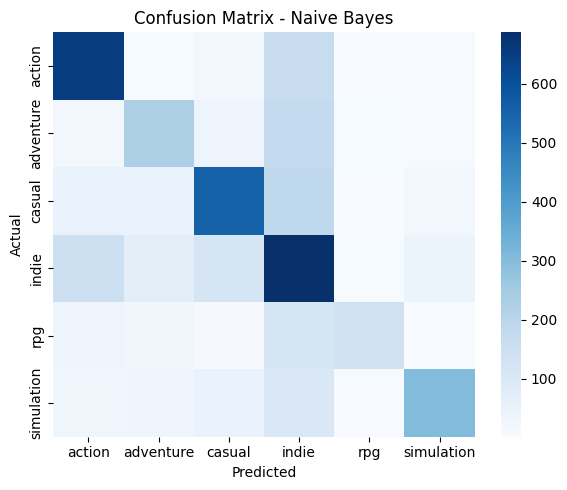

MODEL: K-Nearest Neighbors
              precision    recall  f1-score   support

      action       0.64      0.67      0.66       858
   adventure       0.53      0.40      0.46       482
      casual       0.54      0.65      0.59       869
       indie       0.48      0.47      0.47      1076
         rpg       0.69      0.49      0.58       338
  simulation       0.58      0.62      0.60       524

    accuracy                           0.56      4147
   macro avg       0.58      0.55      0.56      4147
weighted avg       0.56      0.56      0.56      4147



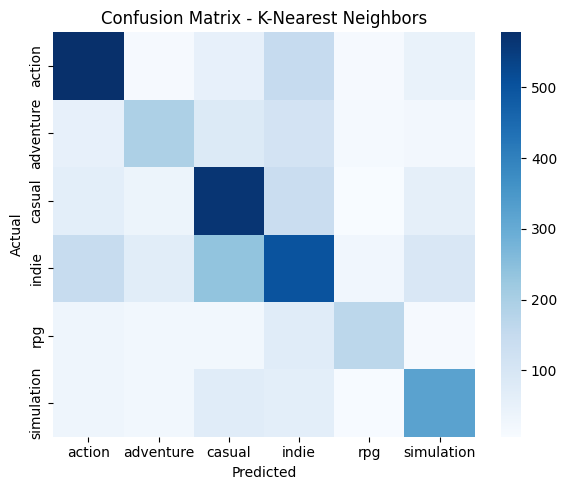

MODEL: Support Vector Machine
              precision    recall  f1-score   support

      action       0.71      0.75      0.73       858
   adventure       0.55      0.50      0.52       482
      casual       0.65      0.67      0.66       869
       indie       0.52      0.54      0.53      1076
         rpg       0.74      0.70      0.72       338
  simulation       0.72      0.67      0.69       524

    accuracy                           0.63      4147
   macro avg       0.65      0.64      0.64      4147
weighted avg       0.63      0.63      0.63      4147



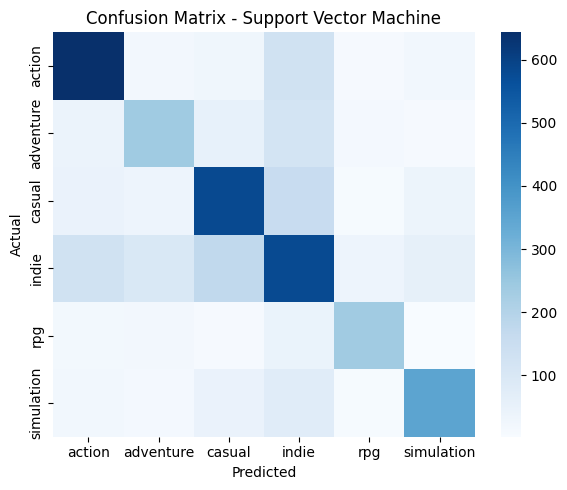

In [25]:
# EVALUASI KETIGA MODEL

evaluate_model(y_test, y_pred_nb,  'Naive Bayes')
evaluate_model(y_test, y_pred_knn, 'K-Nearest Neighbors')
evaluate_model(y_test, y_pred_svm, 'Support Vector Machine')

In [31]:
# PERBANDINGAN PERFORMA ANTAR SKENARIO PREPROCESSING (S1, S2, S3)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

scenarios = {
    'S1_stopword_only': 'synopsis_S1',
    'S2_stemming_only': 'synopsis_S2',
    'S3_stopword_stem': 'synopsis_S3'
}

results = []

for scen_name, text_col in scenarios.items():
    print(f"SKENARIO: {scen_name}  (kolom: {text_col})")
    
    # 1) Ambil teks dan label
    X_text = df_single[text_col]
    y = df_single['genre_main']
    
    # 2) Train-test split (stratified)
    X_train_text, X_test_text, y_train_s, y_test_s = train_test_split(
        X_text, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 3) TF-IDF khusus skenario ini
    tfidf_s = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2)
    )
    X_train_s = tfidf_s.fit_transform(X_train_text)
    X_test_s  = tfidf_s.transform(X_test_text)
    
    # 4) Definisi model-model
    models = {
        'Naive Bayes': MultinomialNB(),
        'KNN (k=19)': KNeighborsClassifier(n_neighbors=19, metric='cosine'),
        'Linear SVM': LinearSVC()
    }
    
    # 5) Training, prediksi, dan simpan metrik
    for model_name, model in models.items():
        model.fit(X_train_s, y_train_s)
        y_pred_s = model.predict(X_test_s)
        
        acc  = accuracy_score(y_test_s, y_pred_s)
        prec = precision_score(y_test_s, y_pred_s, average='macro', zero_division=0)
        rec  = recall_score(y_test_s, y_pred_s, average='macro', zero_division=0)
        f1   = f1_score(y_test_s, y_pred_s, average='macro', zero_division=0)
        
        results.append({
            'Scenario': scen_name,
            'Model': model_name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1
        })

# 6) Tabel ringkasan
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=['Scenario', 'F1'], ascending=[True, False]).reset_index(drop=True)

# Urutkan dari F1 tertinggi ke terendah
results_df = results_df.sort_values(by='F1', ascending=False).reset_index(drop=True)

# Format persentase 2 desimal — standar penulisan tesis
results_display = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    results_display[col] = results_display[col].apply(lambda x: f"{x * 100:.2f}%")

# Rename kolom agar lebih formal untuk tesis
results_display.columns = ['Scenario', 'Model', 'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']

print("Tabel Perbandingan Performa Antar Skenario Preprocessing dan Model")
results_display

SKENARIO: S1_stopword_only  (kolom: synopsis_S1)
SKENARIO: S2_stemming_only  (kolom: synopsis_S2)
SKENARIO: S3_stopword_stem  (kolom: synopsis_S3)
Tabel Perbandingan Performa Antar Skenario Preprocessing dan Model


,Scenario,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,S3_stopword_stem,Linear SVM,63.47%,64.95%,63.77%,64.30%
1,S1_stopword_only,Linear SVM,63.03%,64.38%,63.03%,63.64%
2,S2_stemming_only,Linear SVM,62.79%,64.10%,62.73%,63.35%
3,S1_stopword_only,Naive Bayes,62.09%,66.33%,58.94%,61.31%
4,S3_stopword_stem,Naive Bayes,61.85%,67.20%,58.46%,61.16%
5,S2_stemming_only,Naive Bayes,60.31%,64.61%,57.50%,59.61%
6,S1_stopword_only,KNN (k=19),56.91%,58.78%,55.23%,56.41%
7,S3_stopword_stem,KNN (k=19),56.14%,57.76%,55.04%,55.88%
8,S2_stemming_only,KNN (k=19),55.58%,55.21%,55.90%,55.40%


## Implementasi